# Sprint 2 Risk Scoring

In [2]:
!ls '/project_data/data_asset'
# these are the data files that are available to us
# they can be loaded into this notebook by using the `0100` button in the top right corner

2019q1_clusteredrisk.csv	   op_analysis_01012019_03312019.csv
2019q1_riskscore.csv		   op_analysis_01012020_03312020.csv
2019q2_clusteredrisk.csv	   op_analysis_04012018_06302018.csv
2019q2_riskscore.csv		   op_analysis_04012019_06302019.csv
2019q3_clusteredrisk.csv	   op_analysis_07012018_09302018.csv
2019q3_riskscore.csv		   op_analysis_07012019_09302019.csv
2019q4_clusteredrisk.csv	   op_analysis_10012018_12312018.csv
2019q4_riskscore.csv		   op_analysis_10012019_12312019.csv
2020q1_clusteredrisk.csv	   op_analysis.csv
2020q1_riskscore.csv		   op_analysis_with_nulls.csv
2020q2_clusteredrisk.csv	   op_analysis_with_nulls_with_labels.csv
2020q2_riskscore.csv		   provider-of-interest-export.csv
arcgis_creds_alex.json		   revised_op_analysis_01012018_03312018.csv
colorado-latest.osm.bz2		   revised_op_analysis_01012019_03312019.csv
connect_oracle_db.R		   revised_op_analysis_01012020_03312020.csv
creds.json			   revised_op_analysis_04012019_06302019.csv
joined_df.csv			   revised_op_ana

# 0.0 Imports and functions

## 0.1 Import libraries
- These are all pre-installed in CLoud Pak for Data, so we can import them without having to download anything

In [1]:
# import some libraries into the notebook
# all these libraries are pre-installed in Cloud Pak for Data (dont need to download), so all we have to do is import

import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
import sys

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 0.2 Functions
- Write functions so this code is easily reproduceable and easier to read

In [3]:
# define a preprocessor
# handle scaling and imputation

# inputs: binary columns and continuous columns (even if bounded by [0,1])

def preprocessor_sprint2_refine(binary_feats, num_feats):
    '''
    binary_feats is a python list of the features that are binary
    num_features is a python list of numerical features
    '''
    

#     fill_with_mean = ['Member Count', 'Count Script', 'Sum Dispensed Quantity', 'Total Days', 'PR1', 'PR2', 'PR3', 'PR4']
#     fill_with_zero = [c for c in features if c not in fill_with_mean]
    
    
    scaler = StandardScaler()
    
    numerical_pipeline = make_column_transformer((make_pipeline(SimpleImputer(strategy='constant', fill_value=0)), binary_feats),
                                                 (make_pipeline(SimpleImputer(strategy='constant', fill_value=0), scaler), num_feats),
                                                 remainder='drop')
    
    preprocessor = make_column_transformer((numerical_pipeline, num_feats), 
                                           remainder='drop')
    
    feature_names_reordered = binary_feats+num_feats
    
    return preprocessor, feature_names_reordered

In [4]:
# write function that takes the output of the preprocessor and makes it a df

def apply_data_transform(defined_preprocessor, df, features_names_from_preprocessor, index):
    
    '''
    defined_preprocessor -- the preprocessor returned from the preprocessor_sprint2_refine function
    df -- pandas dataframe of the data we want to apply the scoring on
    features_names_from_preprocessor -- list of feature names returned from the preprocessor_sprint2_refine function
    index -- the indicies defined outside of this function (provider_id, date, etc)
    '''
    
    transformed_q1 = defined_preprocessor.transformers[0][1].fit_transform(df[features_names_from_preprocessor])
    
    # make data a pandas dataframe
    df_refined = pd.DataFrame(data=transformed_q1, columns=features_names_from_preprocessor)
    
    # add the indicies back to the transformed data
    df_intermediate = pd.concat([df[index], df_refined], axis=1)
    
    # set the indicies
    df_for_scoring = df_intermediate.set_index(['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date'])
    
    return df_for_scoring

In [5]:
# write function to make the scoring repeatable
# need to convert the binary back to numeric

def scoring_sum(df, binary_feats, weights):
    '''
    df -- pandas dataframe that has already been transformed and scaled
    binary_feats -- python list of the binary features (PR metrics)
    weights -- python dictionary that contains the PR metrics and the weight assigned. default is all metrics have equal weight
    '''
    for col in binary_feats:
        df[col] = df[col].astype(int)

    
    df = df*weights
    
    df1 = pd.DataFrame()
    
    df1['Sum'] = df.sum(axis=1)
    
    mm_scaler = MinMaxScaler(feature_range=(0,100))
    df1['Risk_Score'] = mm_scaler.fit_transform(df1[['Sum']])
    df1['Bin'] = pd.cut(df1['Risk_Score'], [0,10,20,50,100], labels=['Low Risk', 'Low-Medium Risk', 'Medium-High Risk', 'High Risk'])

    
    return df1[['Sum', 'Risk_Score', 'Bin']]

In [6]:
# TODO - remove 50 for an externally determined threshold
# TODO - replace 50 with a quantile? should make this more robust

def bins_for_scoring_groups(df):
    '''
    df has to have the "Sum", "Risk_Score", and "Bin" columns
    '''
    print(df.groupby(['Bin']).size())
    bad_actors = df.loc[df['Risk_Score']>50].reset_index()['PRSCRB_PROV_LOC_ID'].tolist()
    print('List of suspected bad actors: ', bad_actors)
    
    return bad_actors

## 0.3 Make list of feature types
- This is useful for the preprocesing -- we can treat different columns properly (think binary vs continuous features)
- Also include a to_drop list for features we want to exclude for the time being

In [178]:
# define list of columns before preprocessing
# i can probably add the num_features list and binary_features list here as well. not sure if i should yet?
to_drop = ['PR11']
index = ['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date']
binary_features = ['PR15', 'PR18']

# 1.0 Scoring for  2019
- The final result is a list of `PRSCRB_PROV_LOC_ID` who have a Risk Score > 50
- Use the revised data

## 1.1 Run scoring Q1 2019

In [301]:
# read in 1 quarter of data to start the scoring
# the '/project_data/data_asset' folder contains the quarterly data

df_q1_2019 = pd.read_csv('/project_data/data_asset/revised_op_analysis_01012019_03312019.csv', usecols=['Max Dispense Date', 'Min Dispense Date', 'PRSCRB_PROV_LOC_ID',
       'PR2', 'PR1', 'PR4', 'PR3', 'PR5', 'PR6', 'PR7', 'PR8',
       'PR9', 'PR10', 'PR11', 'PR13', 'PR15', 'PR18', 'PR19', 'PR21', 'PR22',
       'PR23', 'PR24', 'PR25', 'PR26', 'PR27', 'PR28', 'PR29', 'PR30'], dtype={'PR15':'category', 'PR18':'category'})
display(df_q1_2019.head())
print(df_q1_2019.shape)

,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,2019-01-11,2019-01-11,122110,1.000000,28.000000,1.000000,28.000000,0.500000,1.000000,0,0.0,0.0,0.000000,0.000000,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.000000
1,2019-03-31,2019-01-01,165027,3.540230,292.333333,6.844444,565.177778,0.436293,0.017241,49,0.0,0.0,0.149425,0.871753,0.24,0,0,0.0,0.086207,616,0.0,0.0,0.367816,0.0,0.0,0.224138,0,0.005747
2,2019-03-26,2019-01-01,118005,6.250000,249.250000,0.294118,11.729412,0.017986,0.000000,1,0.0,0.0,0.500000,0.000000,0.40,0,0,0.0,0.000000,4,0.0,0.0,0.250000,0.0,0.0,0.250000,0,0.000000
3,2019-03-31,2019-01-09,25176,2.571429,253.000000,0.219512,21.597561,0.050847,0.000000,0,0.0,0.0,0.142857,0.611111,0.28,0,0,0.0,0.000000,3,0.0,0.0,0.000000,0.0,0.0,0.142857,0,0.000000
4,2019-03-19,2019-01-04,114836,2.000000,64.500000,0.106667,3.440000,0.318182,0.000000,1,0.0,0.0,0.000000,0.750000,0.00,0,0,0.0,0.000000,2,0.0,0.0,0.500000,0.0,0.0,0.750000,0,0.000000


(13451, 28)


In [302]:
# make list for preprocessing
features = [c for c in df_q1_2019.columns if c not in index+to_drop]
num_features = df_q1_2019[features].select_dtypes('number').columns.tolist()

In [303]:
# define the data preprocessor
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

# compute the scoring from the preprocessed data
df_for_scoring1 = apply_data_transform(preprocessor_refine, df_q1_2019, features_names, index)

In [304]:
df_q1_2019_final.reset_index(['Max Dispense Date', 'Min Dispense Date'])[['Risk_Score', 'Bin']].head()

,Risk_Score,Bin
PRSCRB_PROV_LOC_ID,,
122110,7.759185,Low Risk
165027,89.604320,High Risk
118005,16.621754,Low-Medium Risk
25176,8.600319,Low Risk
114836,9.203997,Low Risk


### Weights (Optional)
- In case there are some metrics that should be more heavily weighted than others, we can assign the weight we want it to have.


In [305]:
# make a dictionary for weights

scoring_columns = []
for col in df_for_scoring1.columns:
    scoring_columns.append(col)
    
#columns
dictionary_of_weights = dict.fromkeys(scoring_columns,1)
dictionary_of_weights

{'PR15': 1,
 'PR18': 1,
 'PR2': 1,
 'PR1': 1,
 'PR4': 1,
 'PR3': 1,
 'PR5': 1,
 'PR6': 1,
 'PR7': 1,
 'PR8': 1,
 'PR9': 1,
 'PR10': 1,
 'PR13': 1,
 'PR19': 1,
 'PR21': 1,
 'PR22': 1,
 'PR23': 1,
 'PR24': 1,
 'PR25': 1,
 'PR26': 1,
 'PR27': 1,
 'PR28': 1,
 'PR29': 1,
 'PR30': 1}

In [306]:
## if we want to change the weights so some metrics count more than others, we can edit the dictionary directly using the example below

# dictionary_of_weights['PR10'] = 2   # choose the metrics we want to change ('PR10') and the value we want to assign (2)
# dictionary_of_weights               # print the updated dictionary to see the change

In [307]:


#Scale the scoring
df_q1_2019_final = scoring_sum(df_for_scoring1, binary_features, dictionary_of_weights)

# output the bins with sizes
q1_2019_bad_actors = bins_for_scoring_groups(df_q1_2019_final)

Bin
Low Risk            12088
Low-Medium Risk      1147
Medium-High Risk      198
High Risk              16
dtype: int64
List of suspected bad actors:  [165027, 107410, 156800, 122949, 152853, 154518, 139433, 16638, 17522, 157335, 153504, 121269, 111598, 112675, 165594, 166296, 149181]


### 1.1.1 Save risk scores as csv to share results with clustering

### 1.1.2 Find driving PR's

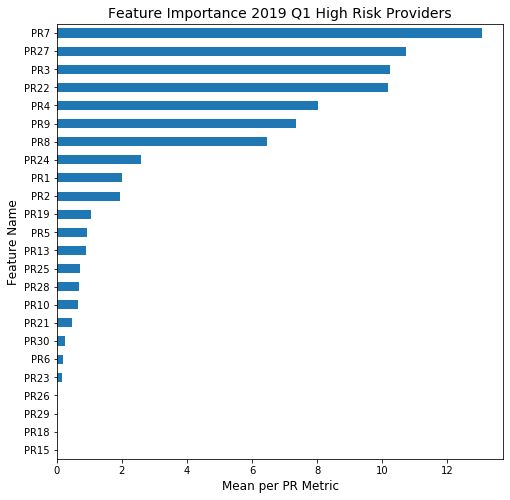

In [350]:
df_for_scoring_imp1 = df_for_scoring1.reset_index()
pd.Series(df_for_scoring_imp1.loc[df_for_scoring_imp1['PRSCRB_PROV_LOC_ID'].isin(q1_2019_bad_actors)].mean()[1:]).sort_values().plot(kind='barh', figsize=(8,8))

plt.title('Feature Importance 2019 Q1 High Risk Providers', fontsize=14)
plt.xlabel('Mean per PR Metric', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

## 1.2 Scoring for Q2 2019
- Use the revised data

In [309]:
# read in 1 quarter of data to start the scoring
# the '/project_data/data_asset' folder contains the quarterly data

df_q2_2019 = pd.read_csv('/project_data/data_asset/revised_op_analysis_04012019_06302019.csv', usecols=['Max Dispense Date', 'Min Dispense Date', 'PRSCRB_PROV_LOC_ID',
       'PR2', 'PR1', 'PR4', 'PR3', 'PR5', 'PR6', 'PR7', 'PR8',
       'PR9', 'PR10', 'PR11', 'PR13', 'PR15', 'PR18', 'PR19', 'PR21', 'PR22',
       'PR23', 'PR24', 'PR25', 'PR26', 'PR27', 'PR28', 'PR29', 'PR30'], dtype={'PR15':'category', 'PR18':'category'})
display(df_q2_2019.head())
print(df_q2_2019.shape)

,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,2019-06-27,2019-04-25,100014,1.666667,170.000000,0.078125,7.968750,0.416667,0.666667,1,0.0,0.0,0.000000,0.400000,0.00,0,0,0.0,0.333333,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,2019-06-30,2019-04-02,100016,2.571429,128.642857,0.400000,20.011111,0.077720,0.000000,0,0.0,0.0,0.142857,0.305556,0.28,0,0,0.0,0.000000,1,0.0,0.0,0.071429,0.0,0.0,0.142857,0.000000,0.071429
2,2019-06-12,2019-04-10,100017,2.222222,72.777778,0.312500,10.234375,0.069307,0.000000,1,0.0,0.0,0.111111,0.250000,0.53,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.222222,0.000000,0.000000
3,2019-06-20,2019-06-06,100023,1.000000,30.000000,0.133333,4.000000,0.005051,0.000000,0,0.0,0.0,0.000000,0.000000,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.500000,0.000000,0.000000
4,2019-06-28,2019-04-01,100027,2.200000,100.000000,0.123596,5.617978,0.080000,0.000000,1,0.0,0.0,0.000000,0.181818,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.400000,0.090909,0.000000


(13449, 28)


In [310]:
features = [c for c in df_q2_2019 if c not in index+to_drop]
num_features = df_q2_2019[features].select_dtypes('number').columns.tolist()

In [311]:
# define the data preprocessor
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

# compute the scoring from the preprocessed data
df_for_scoring2 = apply_data_transform(preprocessor_refine, df_q2_2019, features_names, index)


### Weights (Optional)
- In case there are some metrics that should be more heavily weighted than others, we can assign the weight we want it to have.


In [312]:
# make a dictionary for weights

scoring_columns = []
for col in df_for_scoring2.columns:
    scoring_columns.append(col)
    
#columns
dictionary_of_weights = dict.fromkeys(scoring_columns,1)
dictionary_of_weights

{'PR15': 1,
 'PR18': 1,
 'PR2': 1,
 'PR1': 1,
 'PR4': 1,
 'PR3': 1,
 'PR5': 1,
 'PR6': 1,
 'PR7': 1,
 'PR8': 1,
 'PR9': 1,
 'PR10': 1,
 'PR13': 1,
 'PR19': 1,
 'PR21': 1,
 'PR22': 1,
 'PR23': 1,
 'PR24': 1,
 'PR25': 1,
 'PR26': 1,
 'PR27': 1,
 'PR28': 1,
 'PR29': 1,
 'PR30': 1}

In [313]:
## if we want to change the weights so some metrics count more than others, we can edit the dictionary directly using the example below

# dictionary_of_weights['PR10'] = 2   # choose the metrics we want to change ('PR10') and the value we want to assign (2)
# dictionary_of_weights               # print the updated dictionary to see the change

In [314]:

#Scale the scoring
df_q2_2019_final = scoring_sum(df_for_scoring2, binary_features, dictionary_of_weights)

# output the bins with sizes
q2_2019_bad_actors = bins_for_scoring_groups(df_q2_2019_final)

Bin
Low Risk            12185
Low-Medium Risk      1047
Medium-High Risk      197
High Risk              18
dtype: int64
List of suspected bad actors:  [107410, 122907, 110160, 111813, 149990, 153504, 135733, 136494, 139433, 2755, 156800, 157335, 165027, 165594, 166304, 16638, 170094, 170861, 17522]


### 1.2.2 Find driving PR's

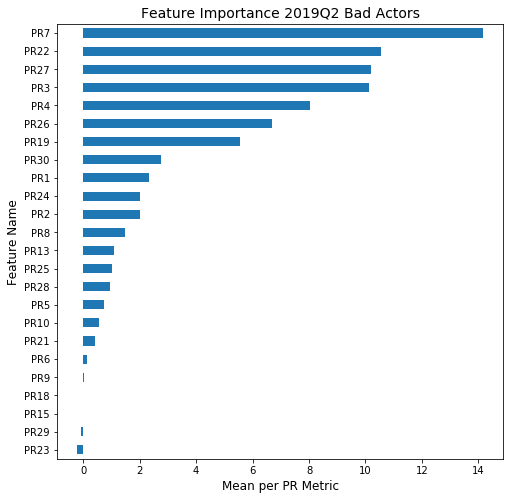

In [315]:
df_for_scoring_imp2 = df_for_scoring2.reset_index()
pd.Series(df_for_scoring_imp2.loc[df_for_scoring_imp2['PRSCRB_PROV_LOC_ID'].isin(q2_2019_bad_actors)].mean()[1:]).sort_values().plot(kind='barh', figsize=(8,8))

plt.title('Feature Importance 2019Q2 Bad Actors', fontsize=14)
plt.xlabel('Mean per PR Metric', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

### 1.2.3 Save risk scores

## 1.3 Scoring for Q3 2019

In [316]:
# read in 1 quarter of data to start the scoring
# the '/project_data/data_asset' folder contains the quarterly data

df_q3_2019 = pd.read_csv('/project_data/data_asset/revised_op_analysis_07012019_09302019.csv', usecols=['Max Dispense Date', 'Min Dispense Date', 'PRSCRB_PROV_LOC_ID',
       'PR2', 'PR1', 'PR4', 'PR3', 'PR5', 'PR6', 'PR7', 'PR8',
       'PR9', 'PR10', 'PR11', 'PR13', 'PR15', 'PR18', 'PR19', 'PR21', 'PR22',
       'PR23', 'PR24', 'PR25', 'PR26', 'PR27', 'PR28', 'PR29', 'PR30'], dtype={'PR15':'category', 'PR18':'category'})
display(df_q3_2019.head())
print(df_q3_2019.shape)

,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,2019-09-26,2019-07-08,102450,1.000000,27.333333,0.111111,3.037037,0.093023,0.000000,0,0.0,0.0,0.0,0.000000,0.00,0,0,0.0,0.000000,0,0.125,0.0,0.111111,0.0,0.0,0.111111,0.0,0.0
1,2019-07-25,2019-07-12,102451,2.000000,75.000000,0.285714,10.714286,0.111111,0.000000,0,0.0,0.0,0.0,0.000000,0.00,0,0,0.0,0.000000,0,0.000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
2,2019-09-26,2019-07-08,102452,1.500000,60.000000,0.037037,1.481481,0.000000,0.000000,0,0.0,0.0,0.0,0.000000,0.00,0,0,0.0,0.000000,0,0.000,0.0,0.000000,0.0,0.0,0.500000,0.0,0.0
3,2019-09-24,2019-07-03,102453,2.444444,154.444444,0.261905,16.547619,0.064220,0.000000,0,0.0,0.0,0.0,0.136364,0.15,0,0,0.0,0.000000,3,0.000,0.0,0.000000,0.0,0.0,0.111111,0.0,0.0
4,2019-09-30,2019-07-07,102454,1.142857,20.857143,0.093023,1.697674,0.084211,0.142857,1,0.0,0.0,0.0,0.625000,0.00,0,0,0.0,0.142857,0,0.000,0.0,0.000000,0.0,0.0,0.285714,0.0,0.0


(13286, 28)


In [317]:
features = [c for c in df_q3_2019 if c not in index+to_drop]
num_features = df_q3_2019[features].select_dtypes('number').columns.tolist()

In [318]:
# define the data preprocessor
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

# compute the scoring from the preprocessed data
df_for_scoring3 = apply_data_transform(preprocessor_refine, df_q3_2019, features_names, index)


### Weights (Optional)
- In case there are some metrics that should be more heavily weighted than others, we can assign the weight we want it to have.


In [319]:
# make a dictionary for weights

scoring_columns = []
for col in df_for_scoring3.columns:
    scoring_columns.append(col)
    
#columns
dictionary_of_weights = dict.fromkeys(scoring_columns,1)
dictionary_of_weights

{'PR15': 1,
 'PR18': 1,
 'PR2': 1,
 'PR1': 1,
 'PR4': 1,
 'PR3': 1,
 'PR5': 1,
 'PR6': 1,
 'PR7': 1,
 'PR8': 1,
 'PR9': 1,
 'PR10': 1,
 'PR13': 1,
 'PR19': 1,
 'PR21': 1,
 'PR22': 1,
 'PR23': 1,
 'PR24': 1,
 'PR25': 1,
 'PR26': 1,
 'PR27': 1,
 'PR28': 1,
 'PR29': 1,
 'PR30': 1}

In [320]:
## if we want to change the weights so some metrics count more than others, we can edit the dictionary directly using the example below

# dictionary_of_weights['PR10'] = 2   # choose the metrics we want to change ('PR10') and the value we want to assign (2)
# dictionary_of_weights               # print the updated dictionary to see the change

In [321]:

#Scale the scoring
df_q3_2019_final = scoring_sum(df_for_scoring3, binary_features, dictionary_of_weights)

# output the bins with sizes
q3_2019_bad_actors = bins_for_scoring_groups(df_q3_2019_final)

Bin
Low Risk            12114
Low-Medium Risk       971
Medium-High Risk      186
High Risk              14
dtype: int64
List of suspected bad actors:  [107410, 117265, 153504, 154518, 139433, 148485, 16188, 165027, 165594, 16638, 170094, 170861, 17522, 4457]


### 1.3.2 Find driving PR's

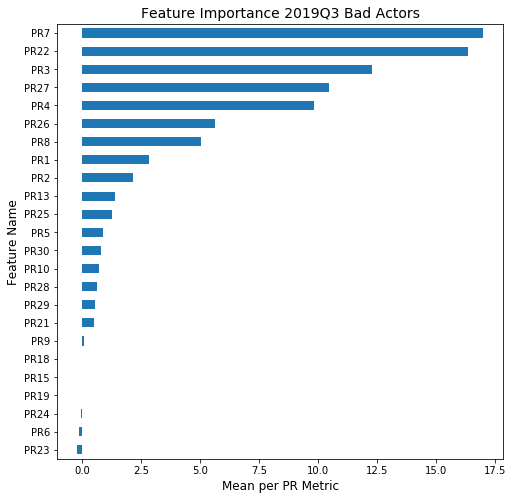

In [322]:
df_for_scoring_imp3 = df_for_scoring3.reset_index()
pd.Series(df_for_scoring_imp3.loc[df_for_scoring_imp3['PRSCRB_PROV_LOC_ID'].isin(q3_2019_bad_actors)].mean()[1:]).sort_values().plot(kind='barh', figsize=(8,8))

plt.title('Feature Importance 2019Q3 Bad Actors', fontsize=14)
plt.xlabel('Mean per PR Metric', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

### 1.3.3 Save risk scores

## 1.4 Scoring for Q4 2019

In [323]:
# read in 1 quarter of data to start the scoring
# the '/project_data/data_asset' folder contains the quarterly data

df_q4_2019 = pd.read_csv('/project_data/data_asset/revised_op_analysis_10012019_12312019.csv', usecols=['Max Dispense Date', 'Min Dispense Date', 'PRSCRB_PROV_LOC_ID',
       'PR2', 'PR1', 'PR4', 'PR3', 'PR5', 'PR6', 'PR7', 'PR8',
       'PR9', 'PR10', 'PR11', 'PR13', 'PR15', 'PR18', 'PR19', 'PR21', 'PR22',
       'PR23', 'PR24', 'PR25', 'PR26', 'PR27', 'PR28', 'PR29', 'PR30'], dtype={'PR15':'category', 'PR18':'category'})
display(df_q4_2019.head())
print(df_q4_2019.shape)

,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,2019-12-23,2019-10-09,100016,3.300,138.100,0.434211,18.171053,0.121622,0.0,0,0.0,0.0,0.1,0.272727,0.52,0,0,0.0,0.0,0,0.0,0.0,0.1,0.0,0.0,0.100,0.060606,0.0
1,2019-12-31,2019-10-26,100017,1.625,40.375,0.194030,4.820896,0.031250,0.0,0,0.0,0.0,0.0,0.384615,0.55,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.125,0.076923,0.0
2,2019-12-09,2019-12-09,100018,1.000,120.000,1.000000,120.000000,0.000000,1.0,0,0.0,0.0,0.0,0.000000,0.00,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0
3,2019-12-28,2019-11-27,100023,1.500,45.000,0.093750,2.812500,0.004505,0.0,0,0.0,0.0,0.0,0.000000,0.00,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0
4,2019-12-23,2019-10-01,100027,4.000,254.000,0.095238,6.047619,0.046512,0.0,0,0.0,0.0,0.0,0.125000,0.00,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000,0.125000,0.0


(13389, 28)


In [324]:
features = [c for c in df_q4_2019 if c not in index+to_drop]
num_features = df_q4_2019[features].select_dtypes('number').columns.tolist()

In [325]:
# define the data preprocessor
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

# compute the scoring from the preprocessed data
df_for_scoring4 = apply_data_transform(preprocessor_refine, df_q4_2019, features_names, index)



### Weights (Optional)
- In case there are some metrics that should be more heavily weighted than others, we can assign the weight we want it to have.


In [326]:
# make a dictionary for weights

scoring_columns = []
for col in df_for_scoring4.columns:
    scoring_columns.append(col)
    
#columns
dictionary_of_weights = dict.fromkeys(scoring_columns,1)
dictionary_of_weights

{'PR15': 1,
 'PR18': 1,
 'PR2': 1,
 'PR1': 1,
 'PR4': 1,
 'PR3': 1,
 'PR5': 1,
 'PR6': 1,
 'PR7': 1,
 'PR8': 1,
 'PR9': 1,
 'PR10': 1,
 'PR13': 1,
 'PR19': 1,
 'PR21': 1,
 'PR22': 1,
 'PR23': 1,
 'PR24': 1,
 'PR25': 1,
 'PR26': 1,
 'PR27': 1,
 'PR28': 1,
 'PR29': 1,
 'PR30': 1}

In [327]:
## if we want to change the weights so some metrics count more than others, we can edit the dictionary directly using the example below

# dictionary_of_weights['PR10'] = 2   # choose the metrics we want to change ('PR10') and the value we want to assign (2)
# dictionary_of_weights               # print the updated dictionary to see the change

In [328]:
#Scale the scoring
df_q4_2019_final = scoring_sum(df_for_scoring4, binary_features, dictionary_of_weights)

# output the bins with sizes
q4_2019_bad_actors = bins_for_scoring_groups(df_q4_2019_final)

Bin
Low Risk            12247
Low-Medium Risk       967
Medium-High Risk      160
High Risk              13
dtype: int64
List of suspected bad actors:  [107410, 117265, 139433, 153504, 154518, 145288, 148485, 131365, 175099, 17522, 2394, 16188, 16638, 170094]


### 1.4.2 Find driving PR's

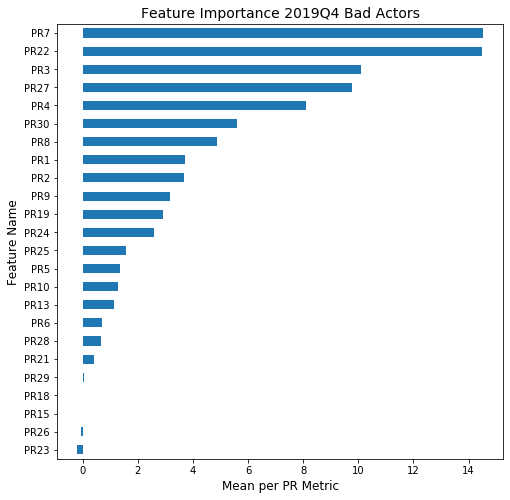

In [329]:
df_for_scoring_imp4 = df_for_scoring4.reset_index()
pd.Series(df_for_scoring_imp4.loc[df_for_scoring_imp4['PRSCRB_PROV_LOC_ID'].isin(q4_2019_bad_actors)].mean()[1:]).sort_values().plot(kind='barh', figsize=(8,8))

plt.title('Feature Importance 2019Q4 Bad Actors', fontsize=14)
plt.xlabel('Mean per PR Metric', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

### 1.4.3 Save csv

## 1.5 See overlap of potential bad actors
- See bad actors and how frequently they appear as high risk
- Plot the number of quarters bad actors appear in the entire year

In [330]:
# this is without using PR11 & PR13
# see how many providers are high risk in both quarters
print('Prescribers who are high risk in every quarter of 2019: ', list(set(q1_2019_bad_actors) & set(q2_2019_bad_actors) & set(q3_2019_bad_actors) & set(q4_2019_bad_actors)))

Prescribers who are high risk in every quarter of 2019:  [153504, 139433, 107410, 17522, 16638]


In [331]:
# this is without using PR11 & PR13
# see how many unique providers are high risk in all quarters
print('Prescribers who are high risk at least once in 2019: ', list(set(q1_2019_bad_actors) | set(q2_2019_bad_actors) | set(q3_2019_bad_actors) | set(q4_2019_bad_actors)))

Prescribers who are high risk at least once in 2019:  [156800, 148485, 145288, 117265, 107410, 152853, 154518, 157335, 166296, 122907, 153504, 166304, 165027, 112675, 131365, 139433, 136494, 121269, 135733, 16188, 149181, 2755, 122949, 111813, 110160, 165594, 2394, 149990, 4457, 170861, 111598, 170094, 17522, 175099, 16638]


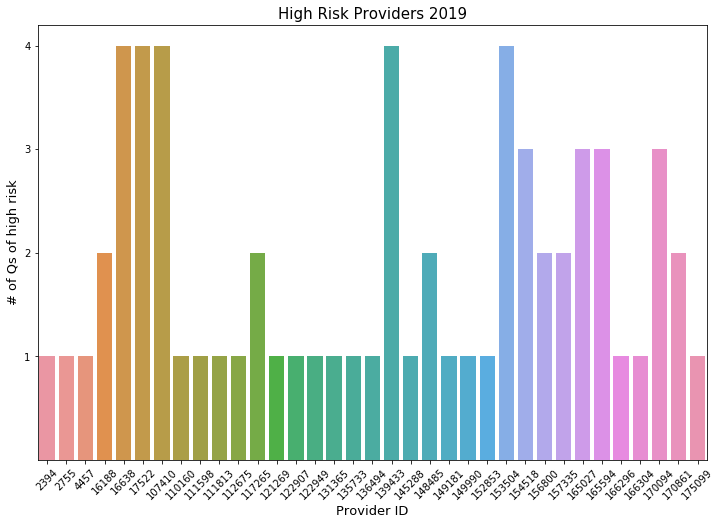

In [351]:
# Plot of how frequently prescribers appear as high risk
# this doesnt 
fig, ax = plt.subplots(figsize=(12,8))
bad_actors_sorted = sorted(q1_2019_bad_actors+q2_2019_bad_actors+q3_2019_bad_actors+q4_2019_bad_actors)
sns.countplot(bad_actors_sorted)
plt.title('High Risk Providers 2019', fontsize=15)
plt.xlabel('Provider ID', fontsize=13)
plt.ylabel('# of Qs of high risk', fontsize=13)
plt.yticks([1,2,3,4])
plt.xticks(rotation=45);

# 2.0 Run scoring for 2020
- use the revised dataset

## 2.1 Scoring for Q1 2020

In [333]:
# read in 1 quarter of data to start the scoring
# the '/project_data/data_asset' folder contains the quarterly data

df_q1_2020 = pd.read_csv('/project_data/data_asset/revised_op_analysis_01012020_03312020.csv', usecols=['Max Dispense Date', 'Min Dispense Date', 'PRSCRB_PROV_LOC_ID',
       'PR2', 'PR1', 'PR4', 'PR3', 'PR5', 'PR6', 'PR7', 'PR8',
       'PR9', 'PR10', 'PR11', 'PR13', 'PR15', 'PR18', 'PR19', 'PR21', 'PR22',
       'PR23', 'PR24', 'PR25', 'PR26', 'PR27', 'PR28', 'PR29', 'PR30'], dtype={'PR15':'category', 'PR18':'category'})
display(df_q1_2020.head())
print(df_q1_2020.shape)

,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,2020-03-20,2020-03-16,100014,1.000000,148.000000,0.400000,59.200000,0.400000,1.000000,0,0.0,0.0,0.000000,0.500000,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.500000,0.0,0.0,0.500000,0.500000,0.0
1,2020-03-26,2020-01-02,100016,2.785714,130.642857,0.458824,21.517647,0.125000,0.000000,1,0.0,0.0,0.142857,0.230769,0.41,0,0,0.0,0.071429,1,0.0,0.0,0.071429,0.0,0.0,0.071429,0.051282,0.0
2,2020-03-31,2020-01-08,100017,2.428571,77.142857,0.202381,6.428571,0.000000,0.142857,1,0.0,0.0,0.000000,0.117647,0.29,0,0,0.0,0.142857,0,0.0,0.0,0.142857,0.0,0.0,0.142857,0.058824,0.0
3,2020-01-24,2020-01-24,100018,1.000000,45.000000,1.000000,45.000000,0.025641,0.000000,0,0.0,0.0,0.000000,0.000000,0.00,0,0,0.0,0.000000,0,0.0,0.0,1.000000,0.0,0.0,1.000000,0.000000,0.0
4,2020-03-20,2020-01-23,100023,2.333333,77.000000,0.120690,3.982759,0.000000,0.000000,0,0.0,0.0,0.000000,0.142857,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0


(13239, 28)


In [334]:
features = [c for c in df_q1_2020 if c not in index+to_drop]
num_features = df_q1_2020[features].select_dtypes('number').columns.tolist()

In [335]:
# define the data preprocessor
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

# compute the scoring from the preprocessed data
df_for_scoring5 = apply_data_transform(preprocessor_refine, df_q1_2020, features_names, index)


### Weights (Optional)
- In case there are some metrics that should be more heavily weighted than others, we can assign the weight we want it to have.


In [336]:
# make a dictionary for weights

scoring_columns = []
for col in df_for_scoring5.columns:
    scoring_columns.append(col)
    
#columns
dictionary_of_weights = dict.fromkeys(scoring_columns,1)
dictionary_of_weights

{'PR15': 1,
 'PR18': 1,
 'PR2': 1,
 'PR1': 1,
 'PR4': 1,
 'PR3': 1,
 'PR5': 1,
 'PR6': 1,
 'PR7': 1,
 'PR8': 1,
 'PR9': 1,
 'PR10': 1,
 'PR13': 1,
 'PR19': 1,
 'PR21': 1,
 'PR22': 1,
 'PR23': 1,
 'PR24': 1,
 'PR25': 1,
 'PR26': 1,
 'PR27': 1,
 'PR28': 1,
 'PR29': 1,
 'PR30': 1}

In [337]:
## if we want to change the weights so some metrics count more than others, we can edit the dictionary directly using the example below

# dictionary_of_weights['PR10'] = 2   # choose the metrics we want to change ('PR10') and the value we want to assign (2)
# dictionary_of_weights               # print the updated dictionary to see the change

In [338]:

#Scale the scoring
df_q1_2020_final = scoring_sum(df_for_scoring5, binary_features, dictionary_of_weights)

# output the bins with sizes
q1_2020_bad_actors = bins_for_scoring_groups(df_q1_2020_final)

Bin
Low Risk            12016
Low-Medium Risk      1008
Medium-High Risk      203
High Risk              10
dtype: int64
List of suspected bad actors:  [101951, 117265, 148485, 153504, 154518, 156890, 157335, 139433, 16638, 170094, 17522]


### 2.1.2 Find driving PR's

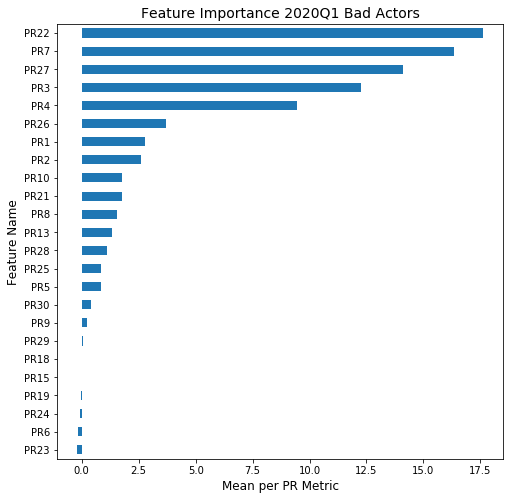

In [339]:
df_for_scoring_imp5 = df_for_scoring5.reset_index()
pd.Series(df_for_scoring_imp5.loc[df_for_scoring_imp5['PRSCRB_PROV_LOC_ID'].isin(q1_2020_bad_actors)].mean()[1:]).sort_values().plot(kind='barh', figsize=(8,8))

plt.title('Feature Importance 2020Q1 Bad Actors', fontsize=14)
plt.xlabel('Mean per PR Metric', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

### 2.1.1 Save csv of risks

## 2.2 Scoring for Q2 2020

In [340]:
# read in 1 quarter of data to start the scoring
# the '/project_data/data_asset' folder contains the quarterly data

df_q2_2020 = pd.read_csv('/project_data/data_asset/revised_op_analysis_04012020_06302020.csv', usecols=['Max Dispense Date', 'Min Dispense Date', 'PRSCRB_PROV_LOC_ID',
       'PR2', 'PR1', 'PR4', 'PR3', 'PR5', 'PR6', 'PR7', 'PR8',
       'PR9', 'PR10', 'PR11', 'PR13', 'PR15', 'PR18', 'PR19', 'PR21', 'PR22',
       'PR23', 'PR24', 'PR25', 'PR26', 'PR27', 'PR28', 'PR29', 'PR30'], dtype={'PR15':'category', 'PR18':'category'})
display(df_q2_2020.head())
print(df_q2_2020.shape)

,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,2020-06-29,2020-04-01,102684,1.400000,44.800000,0.077778,2.488889,0.068966,0.000000,0,0.000000,0.0,0.000000,0.000000,0.00,0,0,0.0,0.000000,1,0.0,0.0,0.000000,0.0,0.0,0.2,0.0,0.0
1,2020-05-29,2020-05-29,102690,1.000000,11.000000,1.000000,11.000000,0.142857,0.000000,0,0.001292,0.0,0.000000,1.000000,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.0
2,2020-06-30,2020-04-01,102691,2.529412,155.294118,0.472527,29.010989,0.095000,0.176471,0,0.003460,0.0,0.058824,0.209302,0.34,0,0,0.0,0.058824,3,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.0
3,2020-06-28,2020-06-28,102699,1.000000,84.000000,1.000000,84.000000,0.000000,0.000000,0,0.000000,0.0,0.000000,0.000000,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,2020-04-23,2020-04-23,10270,1.000000,12.000000,1.000000,12.000000,0.000000,0.000000,0,0.000000,0.0,0.000000,1.000000,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


(12563, 28)


In [341]:
features = [c for c in df_q2_2020 if c not in index+to_drop]
num_features = df_q2_2020[features].select_dtypes('number').columns.tolist()

In [342]:
# define the data preprocessor
preprocessor_refine, features_names = preprocessor_sprint2_refine(binary_features, num_features)

# compute the scoring from the preprocessed data
df_for_scoring6 = apply_data_transform(preprocessor_refine, df_q2_2020, features_names, index)


### Weights (Optional)
- In case there are some metrics that should be more heavily weighted than others, we can assign the weight we want it to have.


In [343]:
# make a dictionary for weights

scoring_columns = []
for col in df_for_scoring6.columns:
    scoring_columns.append(col)
    
#columns
dictionary_of_weights = dict.fromkeys(scoring_columns,1)
dictionary_of_weights

{'PR15': 1,
 'PR18': 1,
 'PR2': 1,
 'PR1': 1,
 'PR4': 1,
 'PR3': 1,
 'PR5': 1,
 'PR6': 1,
 'PR7': 1,
 'PR8': 1,
 'PR9': 1,
 'PR10': 1,
 'PR13': 1,
 'PR19': 1,
 'PR21': 1,
 'PR22': 1,
 'PR23': 1,
 'PR24': 1,
 'PR25': 1,
 'PR26': 1,
 'PR27': 1,
 'PR28': 1,
 'PR29': 1,
 'PR30': 1}

In [344]:
## if we want to change the weights so some metrics count more than others, we can edit the dictionary directly using the example below

# dictionary_of_weights['PR10'] = 2   # choose the metrics we want to change ('PR10') and the value we want to assign (2)
# dictionary_of_weights               # print the updated dictionary to see the change

In [345]:

#Scale the scoring
df_q2_2020_final = scoring_sum(df_for_scoring6, binary_features, dictionary_of_weights)

# output the bins with sizes
q2_2020_bad_actors = bins_for_scoring_groups(df_q2_2020_final)

Bin
Low Risk            11878
Low-Medium Risk       576
Medium-High Risk      101
High Risk               7
dtype: int64
List of suspected bad actors:  [109381, 117265, 120451, 16638, 157335, 170094, 17522]


### 2.2.1 Find driving PR's

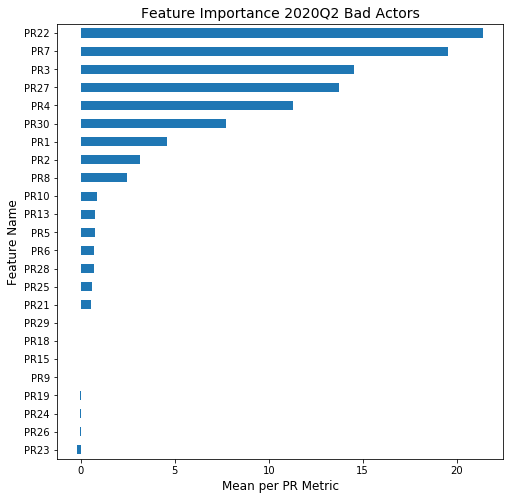

In [346]:
df_for_scoring_imp6 = df_for_scoring6.reset_index()
pd.Series(df_for_scoring_imp6.loc[df_for_scoring_imp6['PRSCRB_PROV_LOC_ID'].isin(q2_2020_bad_actors)].mean()[1:]).sort_values().plot(kind='barh', figsize=(8,8))

plt.title('Feature Importance 2020Q2 Bad Actors', fontsize=14)
plt.xlabel('Mean per PR Metric', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

### 2.2.3 Save csv of risk scores

# 2.3 See overlap of bad actors for 2020

In [347]:
# see how many providers are high risk in both quarters
print('Prescribers who are high risk in all quarters of 2020: ', list(set(q1_2020_bad_actors) & set(q2_2020_bad_actors)))

Prescribers who are high risk in all quarters of 2020:  [170094, 117265, 17522, 157335, 16638]


In [348]:
# see how many unique providers are high risk in all quarters
print('Prescribers who are high risk at least once in 2020: ', list(set(q1_2020_bad_actors) | set(q2_2020_bad_actors)))

Prescribers who are high risk at least once in 2020:  [153504, 120451, 148485, 109381, 139433, 170094, 117265, 17522, 154518, 157335, 156890, 16638, 101951]


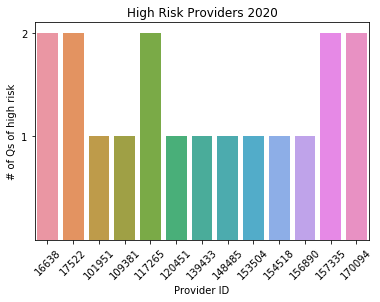

In [370]:
# Plot of how frequently prescribers appear as high risk
bad_actors_sorted = sorted(q1_2020_bad_actors+q2_2020_bad_actors)
sns.countplot(bad_actors_sorted)
plt.title('High Risk Providers 2020')
plt.xlabel('Provider ID')
plt.ylabel('# of Qs of high risk')
plt.yticks([1,2])
plt.xticks(rotation=45);

# Notes and To do's for Sprint 3
- instead of using the bins, we can select the top x percentile of data and report that
- can we use a python dictionary for the weights? --> yes and now we have level of priority. find a good way to make weighting system

In [381]:
# for sprint 2 review deck
df_q1_2019[['PR1']].rename({'PR1':'PR1: Dispensed per Member'}, axis=1).describe()

,PR1: Dispensed per Member
count,13451.000000
mean,71.407807
std,84.278709
min,0.500000
25%,17.550000
50%,42.500000
75%,96.000000
max,1780.000000


In [380]:
# for sprint 2 review deck
df_q1_2019[['PR4']].rename({'PR4':'PR4: Rx per Day'}, axis=1).describe()

,PR4: Rx per Day
count,13451.000000
mean,0.455136
std,0.640325
min,0.022472
25%,0.102041
50%,0.200000
75%,0.712644
max,17.089888
